Today's topics:
* returning more than one value
* keyword arguments, where we name each input in the call
* default values for parameters
* local names and notebook names
* docstrings

# Conductivity versus temperature

Last class we wrote functions with positional arguments.
Today we make them easier to call.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/01/Horno_tubular.jpg/960px-Horno_tubular.jpg" alt="A small tube furnace on a laboratory bench with a perforated steel cover and a digital display reading 400, next to glassware" width=420/>

*Photo by Manuel Almagro Rivas, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Horno_tubular.jpg).*

Above: A [tube furnace](https://en.wikipedia.org/wiki/Tube_furnace) with a controller display reading 400.
A tube furnace can hold a solid-electrolyte sample at a sequence of set temperatures during conductivity measurements.

A lithium ion in a solid electrolyte hops from one site to the next over an energy barrier $E_a$.
A warmer lattice gives more ions enough energy to hop.
Conductivity therefore rises with temperature.

Using a reference conductivity at $T_{ref}$ gives the conductivity at temperature $T$:

$$\sigma(T) = \sigma_{ref}\,\exp\left[-\frac{E_a}{k_B}\left(\frac{1}{T} - \frac{1}{T_{ref}}\right)\right]$$

Here $k_B = 8.617\times10^{-5}$ eV/K and $E_a$ is in eV.
Taking the natural log gives a straight line against $1/T$ with slope $-E_a/k_B$.
Higher temperatures lie to the left.

The [OBELiX dataset](https://github.com/NRC-Mila/OBELiX) from L17 lists a room-temperature conductivity for 599 lithium solid electrolytes (Therrien et al. 2026, [Digital Discovery](https://doi.org/10.1039/D5DD00441A)).

Room temperature is our $T_{ref}$ of 298 K.
What would those conductivities be in a warm battery pack?

In [1]:
#@title Load solid electrolyte structures and conductivities (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd

_file = 'obelix_electrolytes.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_table.columns = [c.strip() for c in _table.columns]
_ok = _table.dropna(subset=['a', 'b', 'c', 'alpha', 'beta', 'gamma'])

cells = []
for _, _row in _ok.head(12).iterrows():
    cells.append({
        'composition': _row['Composition'],
        'a': float(_row['a']), 'b': float(_row['b']), 'c': float(_row['c']),
        'alpha': float(_row['alpha']), 'beta': float(_row['beta']), 'gamma': float(_row['gamma']),
        'sigma': float(_row['Ionic conductivity (S cm-1)']),
    })

sigma_all = _table['Ionic conductivity (S cm-1)'].to_numpy()

print(f'Loaded {len(_table)} solid electrolytes from {_file}')
print(f'  cells:     {len(cells)} records with lattice parameters and conductivity')
print(f'  sigma_all: {len(sigma_all)} conductivities, {sigma_all.min():.1e} to {sigma_all.max():.1e} S/cm')

Loaded 599 solid electrolytes from obelix_electrolytes.csv
  cells:     12 records with lattice parameters and conductivity
  sigma_all: 599 conductivities, 4.2e-18 to 2.5e-02 S/cm


# The function

We write the formula once with positional arguments, as in L17.
The three inputs are the reference conductivity, the activation energy in eV, and the temperature in K.

In [2]:
import numpy as np

def sigma_at(sigma_ref, ea_ev, temp_k):
    k_b = 8.617e-5  # eV/K
    return sigma_ref * np.exp(-(ea_ev / k_b) * (1 / temp_k - 1 / 298))

print(sigma_at(1e-3, 0.3, 333))

0.0034141462149180515


A 1e-3 S/cm conductor with a 0.3 eV barrier reaches 3.4e-3 S/cm at 333 K.

Three plain numbers in a row are easy to scramble.
Was that `0.3` the barrier or the temperature?

# Returning multiple values

A function can `return` several values separated by commas.

We've used functions that do this, like `plt.subplots` and `linregress`.

In [3]:
def my_function(a, b):
    return a + b, a * b

plus, mult = my_function(2, 3)
print(plus)
print(mult)

5
6


The values come back in order.
The names on the left match them by position.

A battery works in the cold and in the heat.
We can return the conductivity at both ends of that range.

In [4]:
def sigma_range(sigma_ref, ea_ev):
    return sigma_at(sigma_ref, ea_ev, 253), sigma_at(sigma_ref, ea_ev, 333)

cold, hot = sigma_range(1e-4, 0.3)
print(cold, hot)
print(hot / cold)

1.2518310957804596e-05 0.0003414146214918052
27.27321782008848


The same electrolyte spans a factor of 27 between 253 K and 333 K.

# Keyword arguments

A call can name each input with `name=value`.
We've done this in plotting calls such as `bins=30`.

Named inputs can go in any order.
A parameter can also have a default value.

In [5]:
def my_function(a, b=2, c=3):
    return a * b + c

print(my_function(2))
print(my_function(2, c=2))
print(my_function(c=2, b=3, a=2))

7
6
8


The first call leaves out `b` and `c` and uses both defaults.
Keywords set any of them, in any order.
Parameters with defaults come after the ones without.

Defaults make `ea_ev` and `temp_k` optional inputs to `sigma_at`.

Many fast inorganic lithium conductors have reported activation energies around 0.2 to 0.5 eV.
We will use 0.3 eV as a representative assumption.
Room temperature is the other natural default.

In [6]:
def sigma_at(sigma_ref, ea_ev=0.3, temp_k=298):
    k_b = 8.617e-5  # eV/K
    return sigma_ref * np.exp(-(ea_ev / k_b) * (1 / temp_k - 1 / 298))

print(sigma_at(1e-3))
print(sigma_at(1e-3, temp_k=333))
print(sigma_at(1e-3, ea_ev=0.4, temp_k=333))

0.001
0.0034141462149180515
0.0051409433923291625


The first call returns the reference value, 1e-3 S/cm.
Raising the temperature to 333 K gives 3.4e-3 S/cm for a 0.3 eV barrier.
With the same reference conductivity, a 0.4 eV barrier gives 5.1e-3 S/cm.

The keywords make the changed quantities explicit.

The default for `ea_ev` is an assumption.
How many of the 599 electrolytes exceed 1e-3 S/cm at 333 K if each has a barrier of 0.2, 0.3 or 0.4 eV?

In [7]:
print('at 298 K:', np.sum(sigma_all > 1e-3))
for ea in [0.2, 0.3, 0.4]:
    print(f'at 333 K, {ea} eV:', np.sum(sigma_at(sigma_all, ea_ev=ea, temp_k=333) > 1e-3))

at 298 K: 98
at 333 K, 0.2 eV: 174
at 333 K, 0.3 eV: 208
at 333 K, 0.4 eV: 232


Warming the pack puts more electrolytes above the target.
A larger assumed barrier produces the larger increase.

Each line below changes only `ea_ev`.

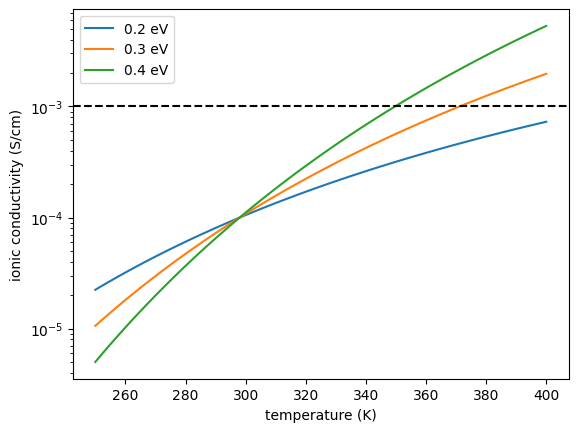

In [8]:
import matplotlib.pyplot as plt

temps = np.linspace(250, 400, 100)

fig, ax = plt.subplots()
for ea in [0.2, 0.3, 0.4]:
    ax.plot(temps, sigma_at(1e-4, ea_ev=ea, temp_k=temps), label=f'{ea} eV')
ax.axhline(1e-3, color='black', linestyle='--')  # the 1e-3 S/cm target
ax.set_yscale('log')
ax.set_xlabel('temperature (K)')
ax.set_ylabel('ionic conductivity (S/cm)')
ax.legend()

All three curves pass through 1e-4 S/cm at 298 K.
The 0.4 eV curve rises fastest and crosses the dashed target first.

A `temp_k` array works because `np.exp` handles arrays, as in L10.

### [Check your understanding]

Write a function `warm_gain(sigma_ref, ea_ev=0.3, t_hot=333, t_cold=298)`.
It returns the conductivity at `t_hot` divided by the conductivity at `t_cold`, using `sigma_at`.

1. Call `warm_gain(1e-4, ea_ev=0.0)`.
   A barrier of zero should give a ratio of exactly 1.0.
2. Call it for a barrier of 0.3 eV with the defaults.
   The ratio should be near 3.4.
3. Call it with `t_cold=253`.
4. Loop over barriers of 0.2, 0.3 and 0.4 eV with `t_cold=253` and print each ratio.

# Scope

A name made inside a function is a **local variable**.
It is available while the function runs and gone after the `return`.

In [9]:
def my_function(x):
    y = x + 2
    z = y * 2
    return z

print(my_function(3))

10


In [10]:
# EXPECTED-ERROR: this cell fails on purpose -- see the surrounding text
print(z)

NameError: name 'z' is not defined

`z` existed only during the call.

Reading goes the other way.
A function can use a name that was defined before it.

In [11]:
constant = 2

def my_function(x):
    y = x + constant
    z = y * 2
    return z

print(my_function(3))

10


A local name can have the same spelling as a notebook name.
The two names refer to different variables.

In [12]:
z = 2
print(my_function(3))
print(z)

10
2


# Docstrings

We call functions without reading their code all the time, like `np.sum`.

`help` shows the **docstring**, the documentation string written for the next user.
That user is often us, months later.

A string in triple quotes on the first line of the body is the docstring.

In [13]:
def my_function(a):
    """Double a number.

    a: an int or a float
    returns: twice the value of a
    """
    return 2 * a

help(my_function)

Help on function my_function in module __main__:

my_function(a)
    Double a number.

    a: an int or a float
    returns: twice the value of a



The `sigma_at` docstring records its units and Arrhenius assumption.

In [14]:
def sigma_at(sigma_ref, ea_ev=0.3, temp_k=298):
    """Ionic conductivity at temp_k, in S/cm.

    sigma_ref:  conductivity at 298 K, in S/cm (a number or an array)
    ea_ev:      activation energy in eV (default: 0.3)
    temp_k:     temperature in K (default: 298)

    Assumes one Arrhenius barrier over the whole temperature range.
    """
    k_b = 8.617e-5  # eV/K
    return sigma_ref * np.exp(-(ea_ev / k_b) * (1 / temp_k - 1 / 298))

help(sigma_at)

Help on function sigma_at in module __main__:

sigma_at(sigma_ref, ea_ev=0.3, temp_k=298)
    Ionic conductivity at temp_k, in S/cm.

    sigma_ref:  conductivity at 298 K, in S/cm (a number or an array)
    ea_ev:      activation energy in eV (default: 0.3)
    temp_k:     temperature in K (default: 298)

    Assumes one Arrhenius barrier over the whole temperature range.



The units, the defaults and the Arrhenius assumption are now stored with the function.
We can read them in any notebook that imports it.

### [Check your understanding]

Write a function `temp_to_reach(sigma_ref, ea_ev=0.3, target=1e-3)` that returns the temperature in K where the conductivity reaches `target`.
Solving the Arrhenius formula for $T$ gives

$$T = \left[\frac{1}{298} - \frac{k_B}{E_a}\ln\frac{\sigma_{target}}{\sigma_{ref}}\right]^{-1}$$

1. Give the function a docstring with the units of each parameter and of the result.
2. Check it with a round trip.
   Call `sigma_at(1e-4, temp_k=T)` with the `T` your function returns for `sigma_ref=1e-4`.
   The result should be 1e-3.
3. Call it with `ea_ev=0.4` and print the temperature.
   How does the temperature change compared with 0.3 eV?

*Use `np.log` for the natural log.*

# Summary

* A function can return several comma-separated values. The caller matches them by position.
* `name=value` in a call names the input. Keyword arguments can go in any order, after the positional ones.
* A default in the `def` line makes an input optional. Parameters without defaults come first.
* A default is an assumption written into the function. `sigma_at` assumes 0.3 eV and 298 K.
* Names made inside a function are local. A function can read notebook names. A local name leaves a notebook name with the same spelling unchanged.
* A docstring on the first line of the body records the units and assumptions. `help(name)` shows it.
* At 333 K, the number of electrolytes above 1e-3 S/cm depends on the barrier we assume.

## Further reading

* VanderPlas, *A Whirlwind Tour of Python*, "Defining and Using Functions"
* The data: Therrien et al., "OBELiX: a curated dataset of crystal structures and experimentally measured ionic conductivities for lithium solid-state electrolytes," *Digital Discovery* 5 (2026) 910-918, [DOI 10.1039/D5DD00441A](https://doi.org/10.1039/D5DD00441A). [Dataset repository](https://github.com/NRC-Mila/OBELiX), CC BY 4.0
* Photo credit: tube furnace, Manuel Almagro Rivas, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/), [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Horno_tubular.jpg)